## Project: PCA and SVD Image Compression

**Name:** Jiaen Qi

**Date:** 07/27/2026



## Abstract:

In this project, I explore image compression and denoising using Singular Value Decomposition (SVD) and Principal Component Analysis (PCA). First, I use truncated SVD to construct low-rank approximations of a grayscale image and examine how the reconstruction quality changes as the rank increases. I then add random noise to the image and apply PCA-based reconstruction to recover its main structure while reducing some of the noise. Reconstruction quality is evaluated using relative error based on the Frobenius norm.


## Setup:

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

## Explain how SVD works

For an $m \times n$ matrix $A$, the singular value decomposition is

$$
A = U\Sigma V^T.
$$

Here:

- $U$ contains the left singular vectors;
- $V$ contains the right singular vectors;
- $\Sigma$ contains the singular values.

The singular values are ordered as

$$
\sigma_1 \geq \sigma_2 \geq \cdots \geq 0.
$$

Larger singular values represent more important information in the matrix.

The matrix can also be written as

$$
A=\sigma_1u_1v_1^T+\sigma_2u_2v_2^T+\cdots+\sigma_ru_rv_r^T.
$$


## SVD Image Compression

A grayscale image can be represented as a matrix

$$
A\in\mathbb{R}^{m\times n},
$$

where each matrix entry represents the brightness of one pixel.

To compress the image, we keep only the first $k$ SVD terms:

$$
A_k=\sigma_1u_1v_1^T+\sigma_2u_2v_2^T+\cdots+\sigma_ku_kv_k^T.
$$

This is called the **rank-k approximation**.

A small $k$ uses less storage but may produce a blurry image. A larger $k$ preserves more detail but requires more storage.

The original image stores

$$
mn
$$

values, while the rank-$k$ approximation stores approximately

$$
k(m+n+1)
$$

values. Therefore, when $k$ is much smaller than $m$ and $n$, SVD compresses the image by keeping only its most important information.

`Essentially`, the **rank-k approximation** is the key part of how and why we can use SVD to compress an image. Once you understand that, you would be good.

## Load and display the chosen image

Image dimensions: (1086, 1448)
Number of values in the original image: 1572528


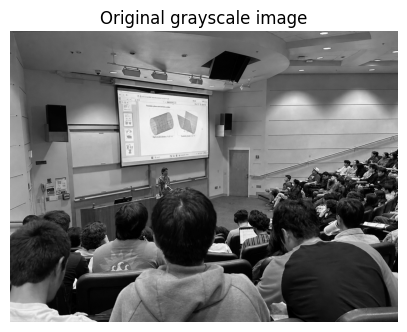

In [ ]:
image = Image.open("MathClass.png").convert("L")
A_image = np.array(image, dtype=float)

print("Image dimensions:", A_image.shape)
print("Number of values in the original image:", A_image.size)

plt.figure(figsize=(5, 5))
plt.imshow(A_image, cmap="gray")
plt.title("Original grayscale image")
plt.axis("off")
plt.show()

This is a picture that I took in a calculus class. In this picture, we can see students are taking notes, looking at the slides, and listening to the professor, and the professor is explaining how to visualize a multi-variable function in three dimensional space.

## Compute the singular values

In [ ]:
U, singular_values, VT = np.linalg.svd(
    A_image,
    full_matrices=False
)

print("Shape of U:", U.shape)
print("Number of singular values:", len(singular_values))
print("Shape of VT:", VT.shape)

Shape of U: (1086, 1086)
Number of singular values: 1086
Shape of VT: (1086, 1448)


We can have a look at the first ten singular values, because after this, we will reconstruct using the first k values.

In [ ]:
U, singular_values, Vt = np.linalg.svd(A_image, full_matrices=False)

def rank_k_image(k):
    return U[:, :k] @ np.diag(singular_values[:k]) @ Vt[:k, :]

print("The first ten singular values are:")
print(np.round(singular_values[:10], 2))

The first ten singular values are:
[136950.69  31097.45  21636.77  18766.34  16896.71  15085.11  12003.44
  10747.1   10354.35   9742.23]


## Compare pictures with different compressions

We will see five pictures with five different ranks of approximation, which are:

- rank - 5
- rank - 10
- rank - 20
- rank - 50
- rank - 100

Also, we can compare them with the orginal image.



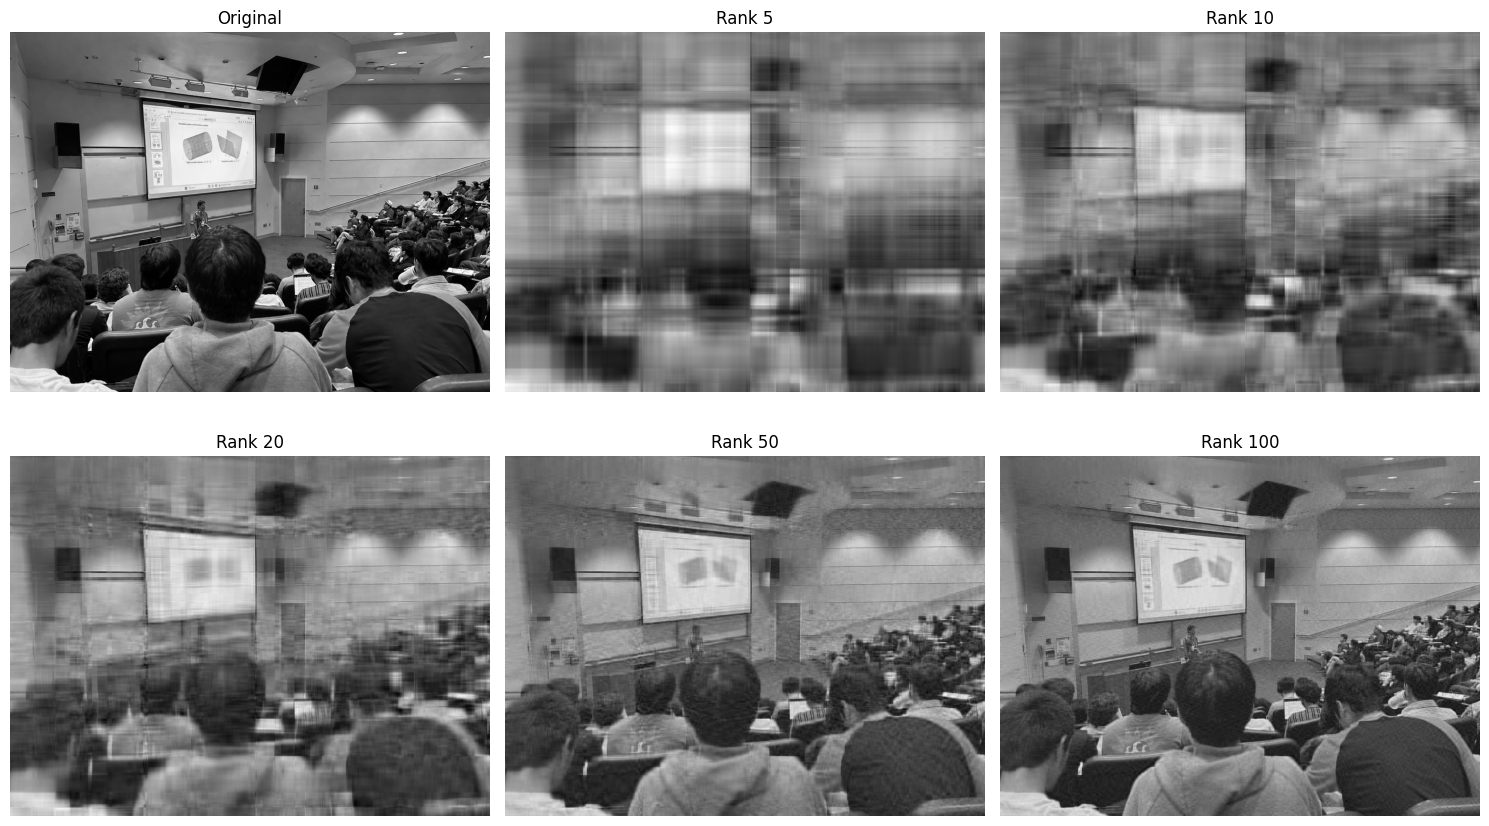

In [ ]:
ranks = [5, 10, 20, 50, 100]

plt.figure(figsize=(15, 9))

# Original image
plt.subplot(2, 3, 1)
plt.imshow(A_image, cmap="gray")
plt.title("Original")
plt.axis("off")

# Rank-k compressed images
for position, k in enumerate(ranks, start=2):
    compressed = rank_k_image(k)

    plt.subplot(2, 3, position)
    plt.imshow(compressed, cmap="gray")
    plt.title(f"Rank {k}")
    plt.axis("off")

plt.tight_layout()
plt.show()

## Compare storage and error

The **relative error**

$$
\frac{\|A-A_k\|_F}{\|A\|_F}
$$

measures how different the compressed matrix is from the original matrix.

- A smaller relative error means the approximation is closer to the original.
- A smaller storage percentage means greater compression.

In [ ]:
ranks = [5, 10, 20, 50, 100]
relative_errors = []

for k in ranks:
    A_k = rank_k_image(k)

    error = np.linalg.norm(
        A_image - A_k,
        ord="fro"
    ) / np.linalg.norm(
        A_image,
        ord="fro"
    )

    relative_errors.append(error)

error_table = pd.DataFrame({
    "Rank k": ranks,
    "Relative Error": relative_errors
})

error_table

,Rank k,Relative Error
0,5,0.287717
1,10,0.228971
2,20,0.177683
3,50,0.120907
4,100,0.082800


As $k$ increases, the relative error decreases and the image becomes clearer. Small values of $k$ remove more image details, so the compressed image appears blurry. Larger values of $k$ preserve more information and produce an image closer to the original.

## Next:

## PCA Reconstruction and Denoising

## How PCA works:

It is a method that reduces the dimension of data while keeping its most important information.

First, the data is centered by subtracting its mean:

$$
X_c = X - \mu.
$$

The principal components are directions that capture the largest variance in the centered data.

- The first principal component captures the most variance.
- The next components capture the remaining variance.
- Smaller components usually contain less important information.

By keeping only the first $k$ principal components, PCA can reconstruct the main structure of the image while removing some smaller components that may contain noise.

## How PCA and SVD are connected

First, center the image matrix:

$$
X_c = X - \mu.
$$

Then compute

$$
X_c = U\Sigma V^T.
$$

The columns of $V$ are the principal component directions, and the singular values in $\Sigma$ measure the importance of each component.

SVD is a matrix decomposition, while PCA is a dimensionality-reduction method that uses centered data. For image denoising, PCA keeps the main components and removes smaller components that may contain noise.

## Add noise to the image

Random noise is added to the original image to create a noisy image:

$$
A_{\text{noisy}} = A + N,
$$

where $N$ is a matrix of random noise.

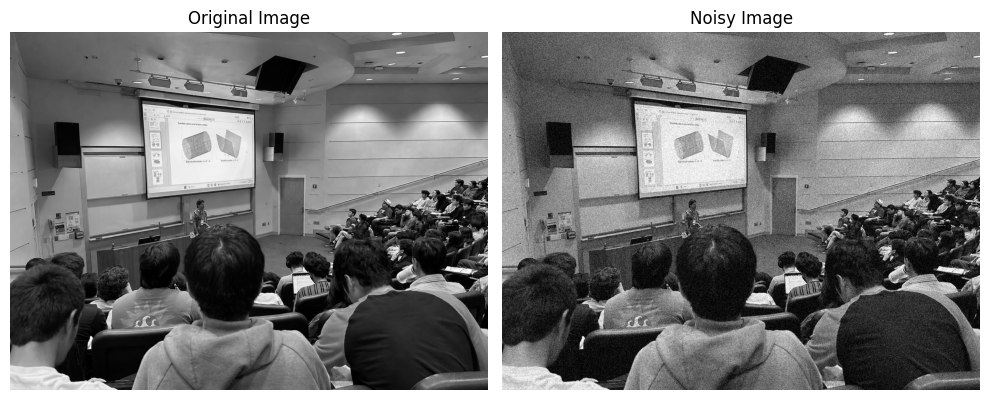

In [ ]:
np.random.seed(2026)

noise = np.random.normal(
    loc=0,
    scale=25,
    size=A_image.shape
)

A_noisy = A_image + noise
A_noisy = np.clip(A_noisy, 0, 255)

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(A_image, cmap="gray")
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(A_noisy, cmap="gray")
plt.title("Noisy Image")
plt.axis("off")

plt.tight_layout()
plt.show()

From above, we can observe that there is some blurriness between the original image and the noisy image, simply because we use np.random to generate random numbers to be the "noise" and add to the original picture. So that's how the "noise" is visualized explicitly here.

## Center the noisy image

Before applying PCA, the noisy image is centered by subtracting the mean of each column:

$$
X_c = A_{\text{noisy}} - \mu,
$$

where $\mu$ contains the column means of the noisy image.

In [ ]:
column_mean = np.mean(A_noisy, axis=0, keepdims=True)

# Center the noisy image
X_centered = A_noisy - column_mean

print("Shape of centered image:", X_centered.shape)
print(
    "Largest absolute column mean:",
    np.max(np.abs(np.mean(X_centered, axis=0)))
)

Shape of centered image: (1086, 1448)
Largest absolute column mean: 3.192338965304494e-13


## Apply SVD to the Centered image

After centering the noisy image, apply SVD:

$$
X_{\text{centered}} = U_{\text{PCA}}\Sigma_{\text{PCA}}V_{\text{PCA}}^T.
$$

The first $k$ components will be used to reconstruct and denoise the image.

In [ ]:
U_pca, singular_values_pca, VT_pca = np.linalg.svd(
    X_centered,
    full_matrices=False
)

print("Shape of U_pca:", U_pca.shape)
print("Number of singular values:", len(singular_values_pca))
print("Shape of VT_pca:", VT_pca.shape)

Shape of U_pca: (1086, 1086)
Number of singular values: 1086
Shape of VT_pca: (1086, 1448)


Then using the first $k$ components, the centered image is approximated by

$$
X_k = U_k\Sigma_kV_k^T.
$$

Then the column mean is added back:

$$
A_k^{\mathrm{PCA}} = X_k + \mu.
$$

In [ ]:
ranks = [5, 10, 20, 50, 100]

def pca_rank_k_image(k):
    X_k = (
        U_pca[:, :k]
        @ np.diag(singular_values_pca[:k])
        @ VT_pca[:k, :]
    )

    return np.clip(X_k + column_mean, 0, 255)

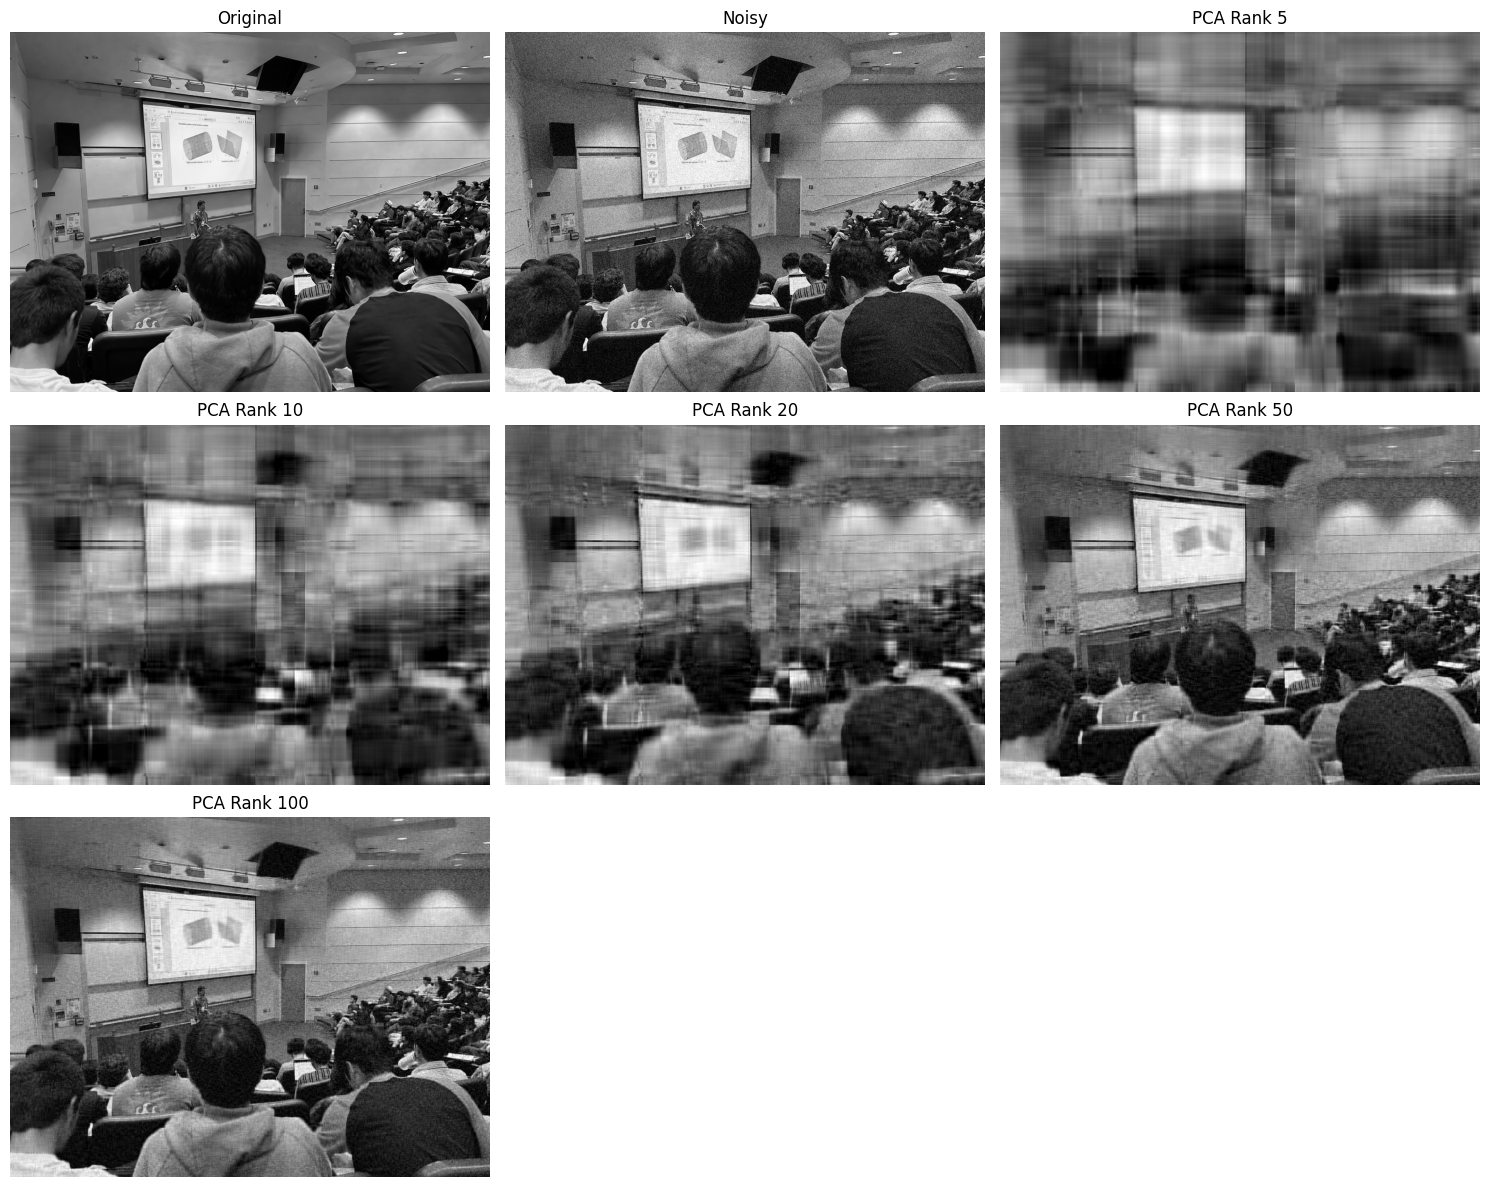

In [ ]:
plt.figure(figsize=(15, 12))

# Original image
plt.subplot(3, 3, 1)
plt.imshow(A_image, cmap="gray")
plt.title("Original")
plt.axis("off")

# Noisy image
plt.subplot(3, 3, 2)
plt.imshow(A_noisy, cmap="gray")
plt.title("Noisy")
plt.axis("off")

# PCA reconstructed images
for position, k in enumerate(ranks, start=3):
    reconstructed = pca_rank_k_image(k)

    plt.subplot(3, 3, position)
    plt.imshow(reconstructed, cmap="gray")
    plt.title(f"PCA Rank {k}")
    plt.axis("off")

plt.tight_layout()
plt.show()

So we can clearly see that the noisy image contains many visible grain-like pixels. As $k$ increases, the PCA reconstructions become clearer and preserve more details.

- At $k=5$ and $k=10$, the main classroom structure is visible, but the images are very blurry.
- At $k=20$, the screen, students, and walls become easier to recognize.
- At $k=50$, the image has a good balance between smoothness and detail, and much of the noise is reduced.
- At $k=100$, the image is the sharpest and has the smallest relative error, but it also keeps slightly more noise.

In my opinion, $k=50$ gives the best-looking denoised image, while $k=100$ gives the best numerical reconstruction among the tested ranks.

## PCA Reconstruction Error

For each PCA reconstructed image $A_k^{\mathrm{PCA}}$, the relative error compared with the original image is

$$
\frac{\left\|A-A_k^{\mathrm{PCA}}\right\|_F}{\|A\|_F}.
$$

A smaller relative error means that the reconstruction is closer to the original clean image.

In [ ]:
pca_errors = []

for k in ranks:
    A_pca_k = pca_rank_k_image(k)

    error = (
        np.linalg.norm(A_image - A_pca_k, ord="fro")
        / np.linalg.norm(A_image, ord="fro")
    )

    pca_errors.append(error)

pca_error_table = pd.DataFrame({
    "Rank k": ranks,
    "Relative Error": pca_errors
})

pca_error_table.style.format({
    "Relative Error": "{:.4f}"
})

,Rank k,Relative Error
0,5,0.2816
1,10,0.2285
2,20,0.1803
3,50,0.1350
4,100,0.1211


In [ ]:
best_position = np.argmin(pca_errors)

best_k = ranks[best_position]
best_error = pca_errors[best_position]

print("Best rank k:", best_k)
print("Smallest relative error:", round(best_error, 4))

Best rank k: 100
Smallest relative error: 0.1211


Among the five tested ranks, we can observe that $k=100$ gives the smallest relative error:

$$
0.1211.
$$

- Therefore, $k=100$ gives the best numerical reconstruction here.
- As $k$ increases, more important image details are preserved and the relative error decreases.
- However, a very large value of $k$ may also preserve more noise.

## Final Conclusion

- This project demonstrates how concepts from linear algebra can be applied directly to image processing.


- Using truncated SVD, I was able to approximate an image with lower-rank matrices while controlling the trade-off between compression and reconstruction quality. As the rank increased, more image information was preserved and the relative reconstruction error decreased.

- I also used PCA to reconstruct an image after adding random noise. PCA can be computed by applying SVD to centered data:

  $$
  X_{\text{centered}}=U\Sigma V^T.
  $$

  `Essentially`, SVD is the matrix calculation, while PCA is the method that uses this calculation to find the most important directions in the data.It preserves the main image structure while removing some lower-importance information and noise.

- When $k$ is too small, the image becomes very blurry. In my results, I could still recognize the classroom, but many details, such as the students and the screen, were unclear.

- SVD gave the better-looking images because it was applied directly to the clean original image. The higher-rank SVD images looked sharper and more natural.

  PCA was still useful because it reduced some noise from the noisy image. Among the tested PCA ranks, I found that

  $$
  k=100
  $$

  gave the best result, with the smallest relative error:

  $$
  0.1211.
  $$

 -  Overall, the project shows how matrix calculation can be used for practical tasks such as image compression, reconstruction, and denoising.
